# Projet 11 — Analyse ACP et clustering

## Objectif

Ce notebook a pour objectif d'identifier des groupes de pays présentant des caractéristiques similaires afin de repérer les marchés les plus pertinents pour le développement international de *La Poule qui chante*.

L'analyse s'appuie sur le jeu de données préparé dans le notebook précédent, contenant 161 pays et 9 variables quantitatives.

Une Analyse en Composantes Principales (ACP) sera d'abord réalisée afin de synthétiser l'information et d'identifier les principales dimensions qui différencient les pays. Des méthodes de clustering seront ensuite appliquées afin de construire des groupes de pays homogènes et d'identifier les marchés présentant le meilleur potentiel pour l'entreprise.

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

donnees = pd.read_csv("../P11/donnees_analyse_P11.csv")

display(donnees.head())
print(donnees.shape)

,Pays,Population_2017,Croissance_population_2012_2017_pct,Disponibilite_volaille_kg_hab_an,Importations_volaille,Production_volaille,Dependance_importations_pct,PIB_habitant_PPA,Stabilite_politique,Importations_volaille_kg_hab
0,Afghanistan,36296.113,16.477889,1.53,29.0,28.0,50.877193,2952.998916,21.244270,0.798984
1,Afrique du Sud,57009.756,7.906280,35.69,514.0,1667.0,24.268178,14573.598084,59.355008,9.016001
2,Albanie,2884.169,-1.026974,16.36,38.0,13.0,80.851064,15359.397458,68.692869,13.175372
3,Algérie,41389.189,10.713956,6.38,2.0,275.0,0.722022,15427.664189,50.016967,0.048322
4,Allemagne,82658.409,2.081915,19.47,842.0,1514.0,48.418631,61965.434290,77.889508,10.186501


(161, 10)


## 1. Préparation des données pour l'ACP

La variable `Pays` est conservée comme identifiant des individus mais n'est pas intégrée aux calculs de l'ACP. L'analyse est réalisée uniquement à partir des neuf variables quantitatives sélectionnées.

In [3]:
# Conservation des pays comme identifiants
pays = donnees["Pays"].copy()

# Sélection des variables quantitatives
X = donnees.drop(columns="Pays").copy()

print("Nombre de pays :", len(pays))
print("Dimensions de X :", X.shape)

display(X.head())

Nombre de pays : 161
Dimensions de X : (161, 9)


,Population_2017,Croissance_population_2012_2017_pct,Disponibilite_volaille_kg_hab_an,Importations_volaille,Production_volaille,Dependance_importations_pct,PIB_habitant_PPA,Stabilite_politique,Importations_volaille_kg_hab
0,36296.113,16.477889,1.53,29.0,28.0,50.877193,2952.998916,21.244270,0.798984
1,57009.756,7.906280,35.69,514.0,1667.0,24.268178,14573.598084,59.355008,9.016001
2,2884.169,-1.026974,16.36,38.0,13.0,80.851064,15359.397458,68.692869,13.175372
3,41389.189,10.713956,6.38,2.0,275.0,0.722022,15427.664189,50.016967,0.048322
4,82658.409,2.081915,19.47,842.0,1514.0,48.418631,61965.434290,77.889508,10.186501


## 2. Standardisation des variables

Les variables utilisées présentent des unités et des échelles différentes. Afin d'éviter qu'une variable influence l'ACP uniquement en raison de son ordre de grandeur, les données sont centrées et réduites avant l'analyse.

Après standardisation, chaque variable possède une moyenne proche de 0 et un écart-type proche de 1.

In [4]:
from sklearn.preprocessing import StandardScaler

# Initialisation du standardiseur
scaler = StandardScaler()

# Centrage et réduction des 9 variables
X_scaled = scaler.fit_transform(X)

# Conversion en DataFrame pour faciliter la lecture
X_scaled = pd.DataFrame(
    X_scaled,
    columns=X.columns,
    index=X.index
)

display(X_scaled.head())

,Population_2017,Croissance_population_2012_2017_pct,Disponibilite_volaille_kg_hab_an,Importations_volaille,Production_volaille,Dependance_importations_pct,PIB_habitant_PPA,Stabilite_politique,Importations_volaille_kg_hab
0,-0.053882,1.453459,-1.185817,-0.325256,-0.282721,0.111280,-0.887484,-3.011855,-0.531316
1,0.077613,0.136267,0.968062,2.230865,0.361362,-0.399226,-0.395637,-0.380147,-0.089923
2,-0.265989,-1.236500,-0.250746,-0.277823,-0.288616,0.686343,-0.362377,0.264672,0.133506
3,-0.021550,0.567720,-0.880011,-0.467556,-0.185657,-0.850971,-0.359488,-1.024978,-0.571639
4,0.240437,-0.758760,-0.054652,3.959540,0.301237,0.064111,1.610245,0.899740,-0.027047


In [5]:
print("Moyennes après standardisation :")
display(X_scaled.mean().round(2))

print("Écarts-types après standardisation :")
display(X_scaled.std(ddof=0).round(2))

Moyennes après standardisation :


Population_2017                        0.0
Croissance_population_2012_2017_pct    0.0
Disponibilite_volaille_kg_hab_an       0.0
Importations_volaille                  0.0
Production_volaille                   -0.0
Dependance_importations_pct           -0.0
PIB_habitant_PPA                      -0.0
Stabilite_politique                    0.0
Importations_volaille_kg_hab          -0.0
dtype: float64

Écarts-types après standardisation :


Population_2017                        1.0
Croissance_population_2012_2017_pct    1.0
Disponibilite_volaille_kg_hab_an       1.0
Importations_volaille                  1.0
Production_volaille                    1.0
Dependance_importations_pct            1.0
PIB_habitant_PPA                       1.0
Stabilite_politique                    1.0
Importations_volaille_kg_hab           1.0
dtype: float64

## 3. Analyse en Composantes Principales

L'ACP est appliquée aux données centrées et réduites afin de synthétiser l'information contenue dans les neuf variables initiales en un nombre plus restreint de composantes principales.

Dans un premier temps, l'ensemble des composantes est calculé afin d'étudier la part de variance expliquée par chacune d'elles et de déterminer le nombre d'axes pertinents à conserver.

In [6]:
from sklearn.decomposition import PCA

# Initialisation de l'ACP
pca = PCA()

# Application de l'ACP aux données standardisées
X_pca = pca.fit_transform(X_scaled)

print("Dimensions après ACP :", X_pca.shape)

Dimensions après ACP : (161, 9)


### 3.1 Variance expliquée par les composantes principales

La part de variance expliquée par chaque composante permet d'évaluer la quantité d'information conservée par les différents axes de l'ACP.

L'analyse de la variance expliquée, des valeurs propres et de la variance cumulée permet de déterminer le nombre de composantes pertinentes à conserver pour l'interprétation.

In [7]:
# Valeurs propres
valeurs_propres = pca.explained_variance_

# Pourcentage de variance expliqué par chaque composante
variance_expliquee = pca.explained_variance_ratio_ * 100

# Pourcentage cumulé de variance expliquée
variance_cumulee = np.cumsum(variance_expliquee)

resultats_pca = pd.DataFrame({
    "Composante": [f"PC{i+1}" for i in range(len(variance_expliquee))],
    "Valeur_propre": valeurs_propres,
    "Variance_expliquee_pct": variance_expliquee,
    "Variance_cumulee_pct": variance_cumulee
})

display(resultats_pca.round(2))

,Composante,Valeur_propre,Variance_expliquee_pct,Variance_cumulee_pct
0,PC1,2.92,32.30,32.30
1,PC2,1.89,20.82,53.11
2,PC3,1.27,14.02,67.13
3,PC4,0.85,9.34,76.48
4,PC5,0.70,7.77,84.25
5,PC6,0.64,7.03,91.28
6,PC7,0.36,3.96,95.24
7,PC8,0.30,3.33,98.57
8,PC9,0.13,1.43,100.00


### 3.2 Éboulis des valeurs propres

L'éboulis des valeurs propres permet de visualiser la part de variance expliquée par chaque composante principale et d'identifier les axes qui concentrent le plus d'information.

Le critère de Kaiser, selon lequel les composantes ayant une valeur propre supérieure à 1 peuvent être retenues, est utilisé comme indication complémentaire.

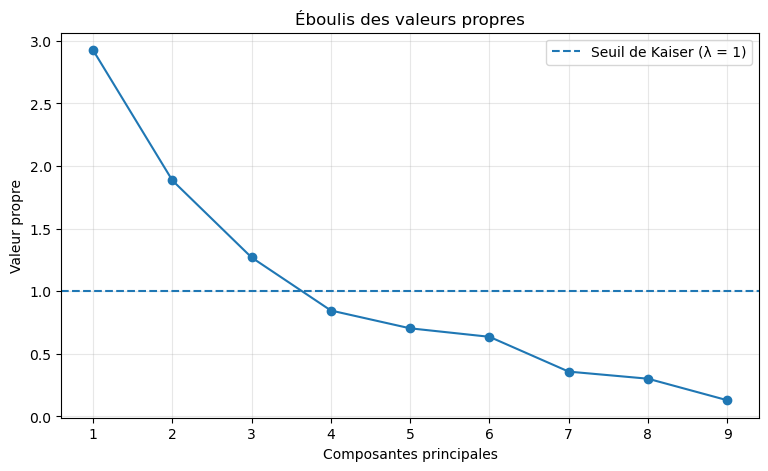

In [8]:
# Éboulis des valeurs propres
plt.figure(figsize=(9, 5))

plt.plot(
    range(1, len(valeurs_propres) + 1),
    valeurs_propres,
    marker="o"
)

# Seuil du critère de Kaiser
plt.axhline(y=1, linestyle="--", label="Seuil de Kaiser (λ = 1)")

plt.xlabel("Composantes principales")
plt.ylabel("Valeur propre")
plt.title("Éboulis des valeurs propres")
plt.xticks(range(1, len(valeurs_propres) + 1))
plt.legend()
plt.grid(alpha=0.3)

plt.show()

### 3.3 Cercle des corrélations

Le cercle des corrélations permet d'étudier la relation entre les variables initiales et les composantes principales.

La direction et la longueur des vecteurs permettent d'identifier les variables qui contribuent à la construction des axes et d'interpréter la signification des composantes principales.

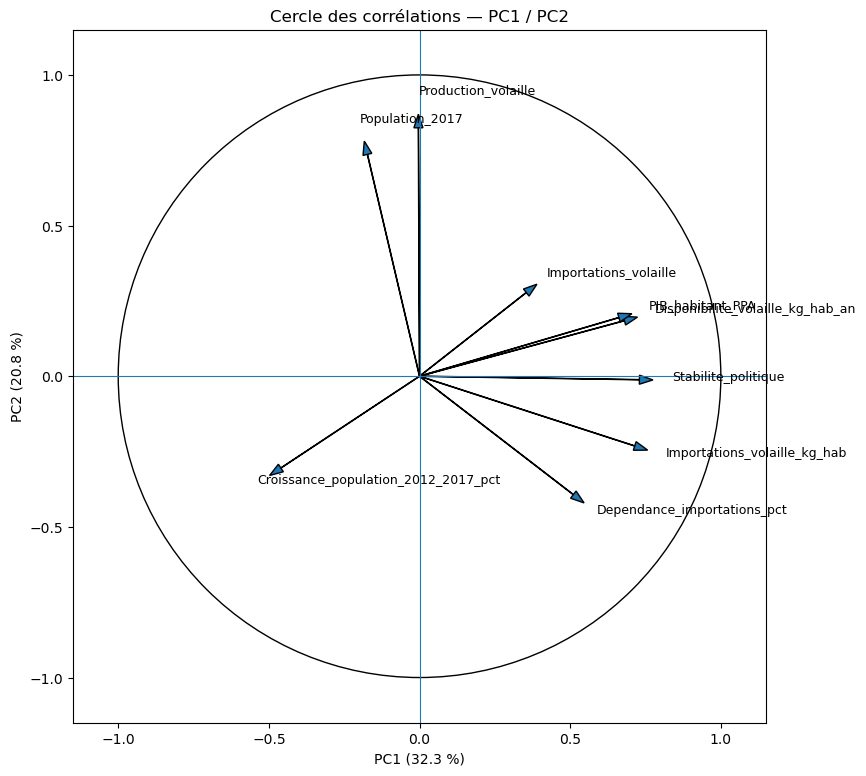

In [9]:
# Coordonnées des variables sur les composantes principales
loadings = pca.components_.T * np.sqrt(pca.explained_variance_)

fig, ax = plt.subplots(figsize=(9, 9))

# Cercle unité
cercle = plt.Circle((0, 0), 1, fill=False)
ax.add_patch(cercle)

# Flèches des variables
for i, variable in enumerate(X.columns):
    ax.arrow(
        0, 0,
        loadings[i, 0],
        loadings[i, 1],
        head_width=0.03,
        length_includes_head=True
    )

    ax.text(
        loadings[i, 0] * 1.08,
        loadings[i, 1] * 1.08,
        variable,
        fontsize=9
    )

# Axes
ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)

ax.set_xlabel(f"PC1 ({variance_expliquee[0]:.1f} %)")
ax.set_ylabel(f"PC2 ({variance_expliquee[1]:.1f} %)")

ax.set_title("Cercle des corrélations — PC1 / PC2")
ax.set_aspect("equal")

plt.show()

### 3.4 Analyse du troisième axe principal

Les trois premières composantes expliquent 67,13 % de la variance totale. Afin de compléter l'interprétation du plan PC1-PC2, le plan PC1-PC3 est étudié pour identifier les variables principalement associées à la troisième composante.

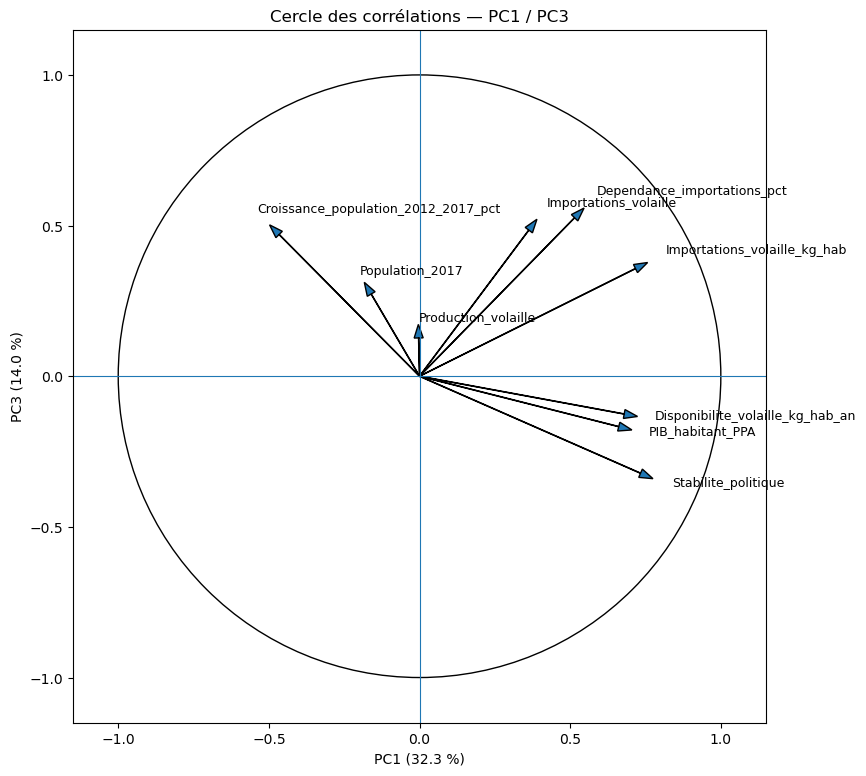

In [10]:
# Cercle des corrélations PC1 / PC3
fig, ax = plt.subplots(figsize=(9, 9))

# Cercle unité
cercle = plt.Circle((0, 0), 1, fill=False)
ax.add_patch(cercle)

# Flèches des variables
for i, variable in enumerate(X.columns):
    ax.arrow(
        0, 0,
        loadings[i, 0],
        loadings[i, 2],
        head_width=0.03,
        length_includes_head=True
    )

    ax.text(
        loadings[i, 0] * 1.08,
        loadings[i, 2] * 1.08,
        variable,
        fontsize=9
    )

ax.axhline(0, linewidth=0.8)
ax.axvline(0, linewidth=0.8)

ax.set_xlim(-1.15, 1.15)
ax.set_ylim(-1.15, 1.15)

ax.set_xlabel(f"PC1 ({variance_expliquee[0]:.1f} %)")
ax.set_ylabel(f"PC3 ({variance_expliquee[2]:.1f} %)")

ax.set_title("Cercle des corrélations — PC1 / PC3")
ax.set_aspect("equal")

plt.show()

### 3.5 Interprétation des composantes principales

L'analyse des cercles de corrélations permet de donner une interprétation économique aux trois premières composantes principales.

- **PC1 (32,3 % de la variance)** est principalement associé au niveau économique, à la stabilité politique ainsi qu'aux caractéristiques de consommation et d'importation de volaille. Les pays situés du côté positif de cet axe présentent davantage ces caractéristiques, tandis que la croissance démographique est davantage associée au côté opposé de l'axe.

- **PC2 (20,8 % de la variance)** est principalement associé à la taille démographique et à la capacité de production de volaille. Les pays ayant des coordonnées élevées sur cet axe correspondent notamment à de grands marchés et/ou de grands producteurs.

- **PC3 (14,0 % de la variance)** complète les deux premiers axes en distinguant notamment des profils davantage associés à la croissance démographique et au recours aux importations de profils davantage associés au niveau économique et à la stabilité politique.

Ces trois composantes expliquent ensemble **67,13 % de la variance totale**. Elles permettent donc de résumer une part importante de l'information contenue dans les neuf variables initiales tout en facilitant l'interprétation des différences entre les pays.

### 3.6 Projection des pays sur le plan factoriel

Les individus, correspondant aux 161 pays étudiés, sont projetés sur les composantes principales afin d'observer leurs positions relatives et d'identifier les pays présentant des profils similaires ou atypiques.

In [11]:
# Création d'un DataFrame contenant les coordonnées des pays
coordonnees_pays = pd.DataFrame(
    X_pca[:, :3],
    columns=["PC1", "PC2", "PC3"]
)

# Ajout des noms des pays
coordonnees_pays["Pays"] = pays.values

display(coordonnees_pays.head())

,PC1,PC2,PC3,Pays
0,-2.922056,-0.846532,1.506626,Afghanistan
1,0.366505,0.956837,1.003459,Afrique du Sud
2,0.468392,-0.425971,-0.405426,Albanie
3,-1.778528,-0.178233,-0.139834,Algérie
4,2.153097,1.602950,1.107589,Allemagne


### 3.7 Projection des individus sur le plan PC1-PC2

La projection des pays sur le premier plan factoriel permet de visualiser les proximités entre les individus. Des pays proches sur ce plan présentent des profils similaires au regard des dimensions représentées par les deux premières composantes.

Les deux premiers axes expliquent 53,11 % de la variance totale ; cette représentation constitue donc une synthèse partielle de l'information.

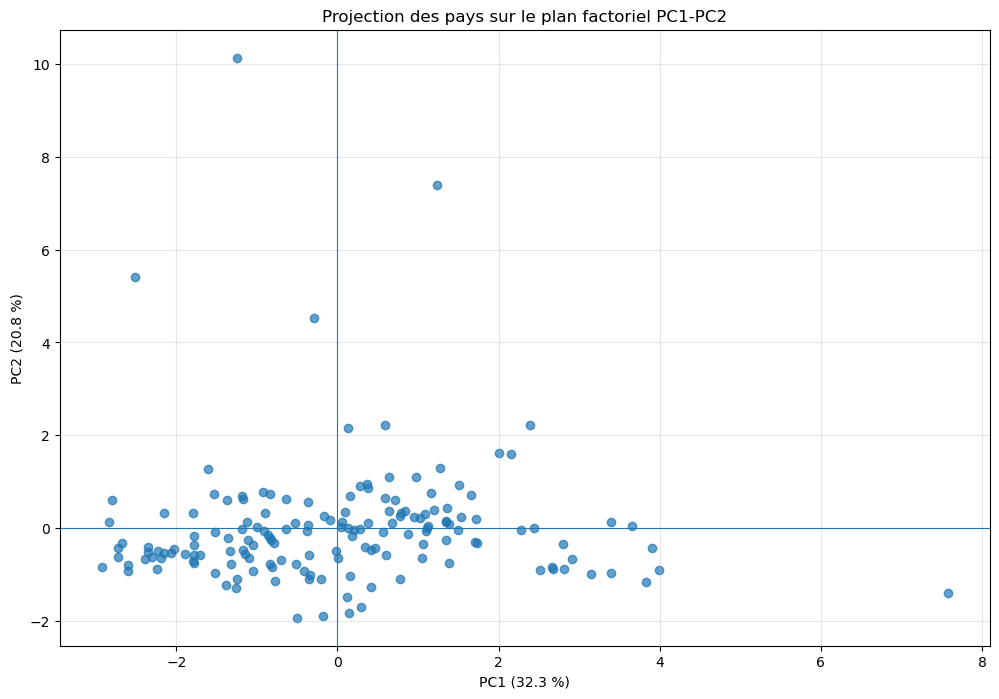

In [12]:
plt.figure(figsize=(12, 8))

plt.scatter(
    coordonnees_pays["PC1"],
    coordonnees_pays["PC2"],
    alpha=0.7
)

plt.axhline(0, linewidth=0.8)
plt.axvline(0, linewidth=0.8)

plt.xlabel(f"PC1 ({variance_expliquee[0]:.1f} %)")
plt.ylabel(f"PC2 ({variance_expliquee[1]:.1f} %)")

plt.title("Projection des pays sur le plan factoriel PC1-PC2")

plt.grid(alpha=0.3)
plt.show()

### 3.8 Identification des pays atypiques

La projection factorielle met en évidence plusieurs pays éloignés du centre du nuage. L'identification de ces individus permet de comprendre quels pays présentent des profils particulièrement atypiques sur les deux premières composantes.

In [13]:
# Pays ayant les coordonnées les plus élevées sur PC1
print("Pays les plus élevés sur PC1 :")
display(
    coordonnees_pays
    .sort_values("PC1", ascending=False)
    .head(5)
)

# Pays ayant les coordonnées les plus élevées sur PC2
print("Pays les plus élevés sur PC2 :")
display(
    coordonnees_pays
    .sort_values("PC2", ascending=False)
    .head(5)
)

# Pays ayant les coordonnées les plus faibles sur PC1
print("Pays les plus faibles sur PC1 :")
display(
    coordonnees_pays
    .sort_values("PC1")
    .head(5)
)

Pays les plus élevés sur PC1 :


,PC1,PC2,PC3,Pays
31,7.572019,-1.404288,5.549947,"Chine, RAS de Hong Kong"
125,3.989899,-0.905823,0.573376,Saint-Vincent-et-les Grenadines
32,3.908359,-0.433886,-0.190197,"Région administrative spéciale de Macao, Chine"
127,3.833673,-1.150508,0.845008,Samoa
156,3.660876,0.042281,0.931304,Émirats arabes unis


Pays les plus élevés sur PC2 :


,PC1,PC2,PC3,Pays
33,-1.244972,10.134192,3.614143,Chine
158,1.239756,7.392451,0.385064,États-Unis
63,-2.515146,5.405522,1.941349,Inde
21,-0.294550,4.516919,0.099616,Brésil
72,2.391322,2.232540,1.467787,Japon


Pays les plus faibles sur PC1 :


,PC1,PC2,PC3,Pays
0,-2.922056,-0.846532,1.506626,Afghanistan
102,-2.830940,0.135593,0.776372,Nigéria
108,-2.794367,0.607831,0.759612,Pakistan
133,-2.725887,-0.425461,0.481958,Soudan
89,-2.722533,-0.619257,0.559323,Mali


## 4. Classification Ascendante Hiérarchique (CAH)

La Classification Ascendante Hiérarchique permet de regrouper progressivement les pays présentant des profils similaires.

La classification est réalisée à partir des neuf variables quantitatives centrées et réduites. La méthode de Ward est utilisée afin de construire des groupes aussi homogènes que possible en limitant l'augmentation de la variance intra-classe lors des différentes fusions.

Le dendrogramme permettra ensuite d'étudier la structure hiérarchique des regroupements et d'orienter le choix du nombre de clusters.

In [85]:
from scipy.cluster.hierarchy import linkage, dendrogram

# Calcul de la classification hiérarchique avec la méthode de Ward
Z = linkage(
    X_scaled,
    method="ward"
)

print("Dimensions de la matrice de liaison :", Z.shape)

Dimensions de la matrice de liaison : (160, 4)


### 4.1 Dendrogramme

Le dendrogramme représente les différentes étapes de fusion entre les pays et les groupes de pays. La hauteur des fusions permet d'observer leur niveau de dissimilarité et d'identifier des ruptures pouvant guider le choix du nombre de clusters.

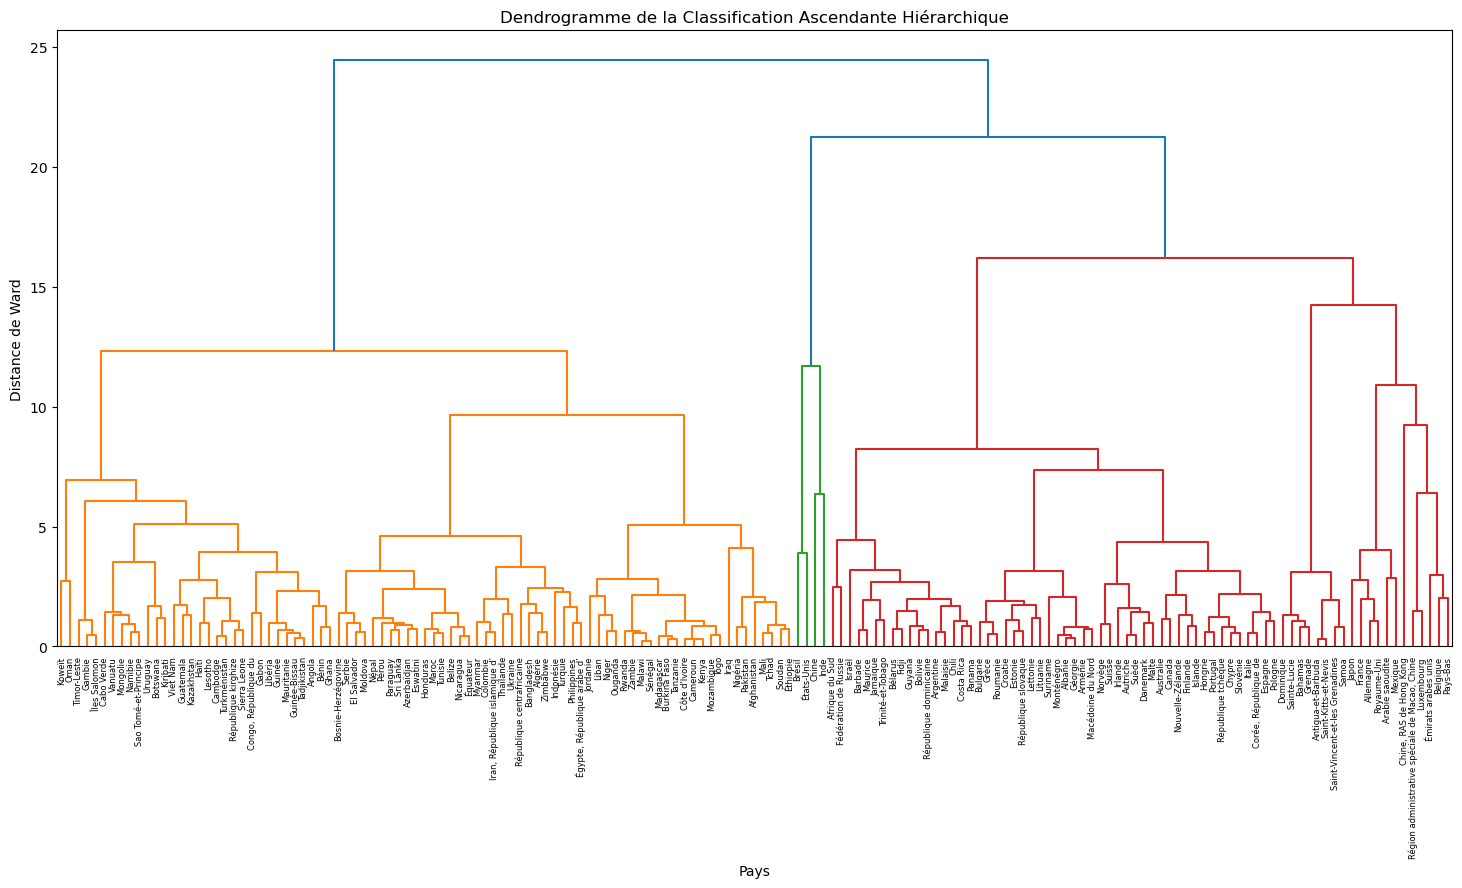

In [86]:
plt.figure(figsize=(18, 8))

dendrogram(
    Z,
    labels=pays.values,
    leaf_rotation=90,
    leaf_font_size=6
)

plt.xlabel("Pays")
plt.ylabel("Distance de Ward")
plt.title("Dendrogramme de la Classification Ascendante Hiérarchique")

plt.show()

### 4.2 Choix du nombre de clusters

Le dendrogramme met en évidence plusieurs ruptures dans les distances de fusion, suggérant l'existence de groupes de pays distincts.

Afin de compléter cette analyse visuelle et de guider le choix du nombre de clusters, plusieurs découpages de la classification sont comparés à l'aide du score de silhouette. Ce score permet d'évaluer à la fois la cohésion des individus au sein d'un même cluster et la séparation entre les différents clusters.

In [87]:
from scipy.cluster.hierarchy import fcluster
from sklearn.metrics import silhouette_score

resultats_cah = []

for k in range(2, 8):
    
    # Découpage de l'arbre en k clusters
    clusters = fcluster(
        Z,
        t=k,
        criterion="maxclust"
    )
    
    # Calcul du score de silhouette
    score = silhouette_score(
        X_scaled,
        clusters
    )
    
    resultats_cah.append({
        "Nombre_clusters": k,
        "Score_silhouette": score
    })

resultats_cah = pd.DataFrame(resultats_cah)

display(resultats_cah.round(3))

,Nombre_clusters,Score_silhouette
0,2,0.244
1,3,0.261
2,4,0.237
3,5,0.272
4,6,0.249
5,7,0.255


Parmi les solutions testées, le découpage en **5 clusters** présente le score de silhouette le plus élevé (**0,272**).

Bien que ce score indique une séparation modérée entre les groupes, cette solution constitue le meilleur compromis parmi les découpages étudiés. Le choix de cinq clusters est donc retenu pour la CAH, sous réserve de vérifier la taille et l'interprétabilité des groupes obtenus.

### 4.3 Construction des clusters de la CAH

Le dendrogramme et l'analyse du score de silhouette conduisent à retenir une partition en cinq groupes. Les pays sont donc répartis dans cinq clusters à partir de la classification hiérarchique obtenue avec la méthode de Ward.

In [88]:
# Découpage final de la CAH en 5 clusters
clusters_cah = fcluster(
    Z,
    t=5,
    criterion="maxclust"
)

# Ajout du cluster aux pays
resultats_cah_pays = donnees.copy()
resultats_cah_pays["Cluster_CAH"] = clusters_cah

# Nombre de pays par cluster
taille_clusters_cah = (
    resultats_cah_pays["Cluster_CAH"]
    .value_counts()
    .sort_index()
)

display(taille_clusters_cah)

Cluster_CAH
1    85
2     4
3    52
4     8
5    12
Name: count, dtype: int64

### 4.4 Profil des clusters de la CAH

Afin d'interpréter les groupes obtenus, le profil moyen de chaque cluster est étudié à partir des variables standardisées.

Une valeur positive indique que le cluster se situe en moyenne au-dessus de la moyenne globale pour la variable considérée, tandis qu'une valeur négative indique un niveau inférieur à la moyenne globale.

In [89]:
# Ajout des clusters aux données standardisées
profil_cah = X_scaled.copy()
profil_cah["Cluster_CAH"] = clusters_cah

# Profil moyen standardisé de chaque cluster
profil_moyen_cah = profil_cah.groupby("Cluster_CAH").mean()

display(profil_moyen_cah.round(2))

,Population_2017,Croissance_population_2012_2017_pct,Disponibilite_volaille_kg_hab_an,Importations_volaille,Production_volaille,Dependance_importations_pct,PIB_habitant_PPA,Stabilite_politique,Importations_volaille_kg_hab
Cluster_CAH,,,,,,,,,
1,-0.09,0.58,-0.62,-0.27,-0.18,-0.10,-0.60,-0.58,-0.34
2,4.94,-0.46,0.58,0.28,5.39,-0.85,0.13,-0.30,-0.56
3,-0.19,-0.75,0.51,-0.14,-0.10,-0.19,0.56,0.66,-0.12
4,-0.28,-0.58,2.09,-0.42,-0.29,1.05,-0.13,1.08,3.16
5,0.00,-0.30,0.56,2.69,0.13,1.16,1.88,0.66,1.03


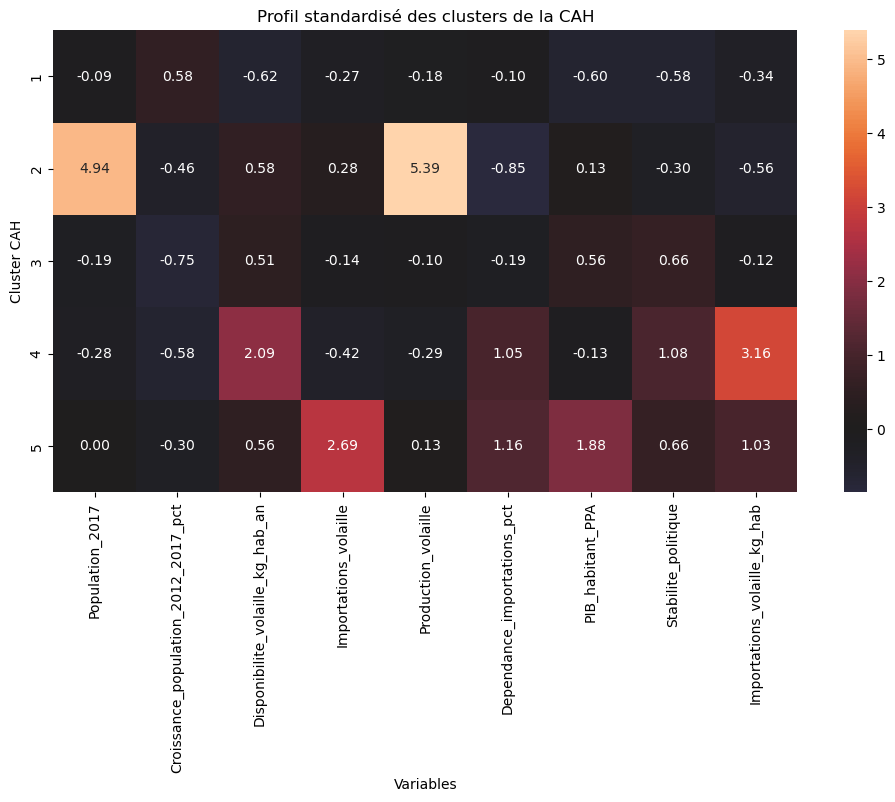

In [90]:
plt.figure(figsize=(12, 6))

sns.heatmap(
    profil_moyen_cah,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Profil standardisé des clusters de la CAH")
plt.xlabel("Variables")
plt.ylabel("Cluster CAH")

plt.show()

### 4.5 Composition des clusters

L'analyse des profils moyens met en évidence des caractéristiques différentes entre les cinq groupes. La composition des clusters est maintenant étudiée afin d'identifier les pays correspondant à ces différents profils.

In [91]:
for cluster in sorted(resultats_cah_pays["Cluster_CAH"].unique()):
    
    pays_cluster = (
        resultats_cah_pays[
            resultats_cah_pays["Cluster_CAH"] == cluster
        ]["Pays"]
        .sort_values()
        .tolist()
    )
    
    print(f"\nCluster {cluster} ({len(pays_cluster)} pays) :")
    print(", ".join(pays_cluster))


Cluster 1 (85 pays) :
Afghanistan, Algérie, Angola, Azerbaïdjan, Bangladesh, Belize, Bosnie-Herzégovine, Botswana, Burkina Faso, Bénin, Cabo Verde, Cambodge, Cameroun, Colombie, Congo, République du, Côte d'Ivoire, El Salvador, Eswatini, Gabon, Gambie, Ghana, Guatemala, Guinée, Guinée-Bissau, Haïti, Honduras, Indonésie, Iran, République islamique d’, Iraq, Jordanie, Kazakhstan, Kenya, Kiribati, Koweït, Lesotho, Liban, Libéria, Madagascar, Malawi, Mali, Maroc, Mauritanie, Moldova, Mongolie, Mozambique, Myanmar, Namibie, Nicaragua, Niger, Nigéria, Népal, Oman, Ouganda, Pakistan, Paraguay, Philippines, Pérou, Rwanda, République centrafricaine, République kirghize, Sao Tomé-et-Principe, Serbie, Sierra Leone, Soudan, Sri Lanka, Sénégal, Tadjikistan, Tanzanie, Tchad, Thaïlande, Timor-Leste, Togo, Tunisie, Turkménistan, Turquie, Ukraine, Uruguay, Vanuatu, Viet Nam, Zambie, Zimbabwe, Égypte, République arabe d’, Équateur, Éthiopie, Îles Salomon

Cluster 2 (4 pays) :
Brésil, Chine, Inde, États

## 5. Classification par K-Means

La méthode K-Means est utilisée comme seconde approche de clustering afin de compléter les résultats obtenus avec la CAH.

Plusieurs nombres de clusters sont testés. Le choix de la partition est étudié à partir de l'inertie intra-classe et du score de silhouette.

In [92]:
#Ajout de ce paramètre car warning présent après execution de cette cellule
import warnings

warnings.filterwarnings(
    "ignore",
    message="KMeans is known to have a memory leak on Windows with MKL"
)

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score

resultats_kmeans = []

for k in range(2, 11):

    kmeans = KMeans(
        n_clusters=k,
        random_state=42,
        n_init=20
    )

    clusters_kmeans = kmeans.fit_predict(X_scaled)

    score = silhouette_score(
        X_scaled,
        clusters_kmeans
    )

    resultats_kmeans.append({
        "Nombre_clusters": k,
        "Inertie": kmeans.inertia_,
        "Score_silhouette": score
    })

resultats_kmeans = pd.DataFrame(resultats_kmeans)

display(resultats_kmeans.round(3))

# Affichage complet des résultats K-Means
print(resultats_kmeans.to_string(index=False))

,Nombre_clusters,Inertie,Score_silhouette
0,2,1132.485,0.252
1,3,911.824,0.269
2,4,764.156,0.275
3,5,684.427,0.247
4,6,595.392,0.277
5,7,518.514,0.293
6,8,462.037,0.252
7,9,414.891,0.274
8,10,380.901,0.257


 Nombre_clusters     Inertie  Score_silhouette
               2 1132.485404          0.252074
               3  911.823904          0.268777
               4  764.155986          0.274632
               5  684.427472          0.246869
               6  595.392205          0.276781
               7  518.513531          0.292502
               8  462.037378          0.251901
               9  414.891358          0.274486
              10  380.901096          0.256865


### 5.1 Choix du nombre de clusters

Le nombre de clusters est étudié à partir de deux indicateurs complémentaires : l'inertie intra-classe et le score de silhouette.

L'évolution de l'inertie permet de rechercher un éventuel point de rupture, tandis que le score de silhouette permet d'évaluer la cohésion et la séparation des groupes obtenus.

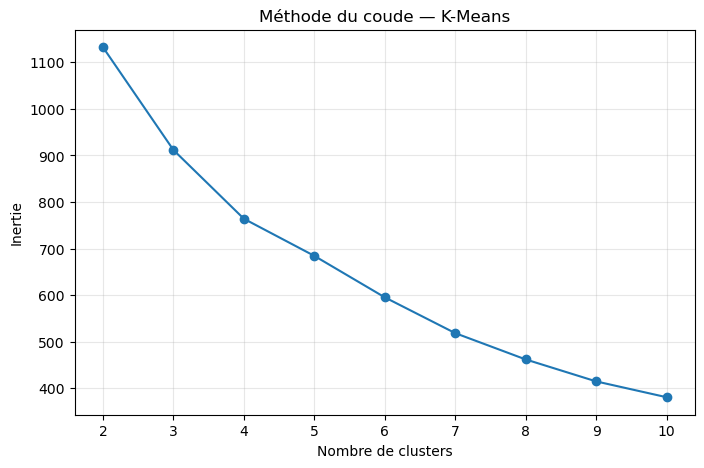

In [93]:
plt.figure(figsize=(8, 5))

plt.plot(
    resultats_kmeans["Nombre_clusters"],
    resultats_kmeans["Inertie"],
    marker="o"
)

plt.xlabel("Nombre de clusters")
plt.ylabel("Inertie")
plt.title("Méthode du coude — K-Means")
plt.grid(alpha=0.3)

plt.show()

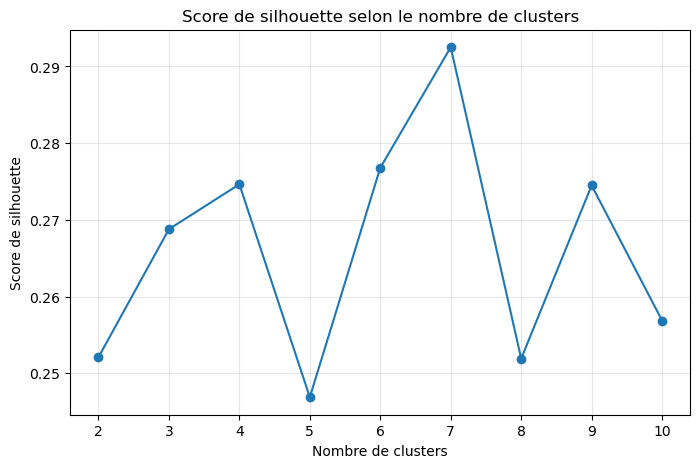

In [94]:
plt.figure(figsize=(8, 5))

plt.plot(
    resultats_kmeans["Nombre_clusters"],
    resultats_kmeans["Score_silhouette"],
    marker="o"
)

plt.xlabel("Nombre de clusters")
plt.ylabel("Score de silhouette")
plt.title("Score de silhouette selon le nombre de clusters")
plt.grid(alpha=0.3)

plt.show()

L'analyse des différentes partitions montre que le score de silhouette atteint son maximum pour **7 clusters (0,293)** parmi les solutions testées de 2 à 10 groupes.

L'inertie diminue progressivement avec l'augmentation du nombre de clusters, sans faire apparaître un coude unique particulièrement marqué. Le score de silhouette est donc utilisé comme critère complémentaire pour retenir une partition en **7 clusters** pour la méthode K-Means.

Cette solution sera ensuite comparée à la partition en cinq groupes obtenue avec la CAH.

### 5.2 Construction de la partition finale K-Means

L'analyse de l'inertie et du score de silhouette conduit à retenir une partition en sept groupes.

Un modèle K-Means final est donc entraîné avec sept clusters afin d'étudier leur taille, leur profil et leur composition.

In [95]:
# Modèle K-Means final avec 7 clusters
kmeans_final = KMeans(
    n_clusters=7,
    random_state=42,
    n_init=20
)

clusters_kmeans_final = kmeans_final.fit_predict(X_scaled)

# Ajout des clusters aux données
resultats_kmeans_pays = donnees.copy()
resultats_kmeans_pays["Cluster_KMeans"] = clusters_kmeans_final

# Nombre de pays par cluster
taille_clusters_kmeans = (
    resultats_kmeans_pays["Cluster_KMeans"]
    .value_counts()
    .sort_index()
)

display(taille_clusters_kmeans)

Cluster_KMeans
0    22
1    61
2    12
3     2
4     2
5    54
6     8
Name: count, dtype: int64

### 5.3 Profil des clusters K-Means

Les caractéristiques moyennes standardisées des sept clusters sont étudiées afin d'identifier les dimensions qui différencient les groupes obtenus.

Les valeurs positives indiquent des niveaux supérieurs à la moyenne globale, tandis que les valeurs négatives indiquent des niveaux inférieurs à cette moyenne.

In [96]:
# Ajout des clusters aux données standardisées
profil_kmeans = X_scaled.copy()
profil_kmeans["Cluster_KMeans"] = clusters_kmeans_final

# Profil moyen standardisé
profil_moyen_kmeans = (
    profil_kmeans
    .groupby("Cluster_KMeans")
    .mean()
)

display(profil_moyen_kmeans.round(2))

,Population_2017,Croissance_population_2012_2017_pct,Disponibilite_volaille_kg_hab_an,Importations_volaille,Production_volaille,Dependance_importations_pct,PIB_habitant_PPA,Stabilite_politique,Importations_volaille_kg_hab
Cluster_KMeans,,,,,,,,,
0,-0.24,0.88,-0.64,-0.11,-0.28,1.41,-0.58,0.02,0.08
1,-0.20,-0.73,0.36,-0.19,-0.13,-0.19,0.52,0.65,-0.15
2,-0.27,-0.25,1.90,0.22,-0.29,1.40,0.72,1.01,2.99
3,8.48,-0.43,-0.82,0.71,3.99,-0.84,-0.51,-0.39,-0.57
4,1.41,-0.48,1.99,-0.15,6.80,-0.86,0.76,-0.22,-0.56
5,-0.01,0.61,-0.68,-0.33,-0.13,-0.63,-0.66,-0.99,-0.52
6,0.17,-0.39,0.49,3.48,0.39,0.14,0.96,0.25,0.18


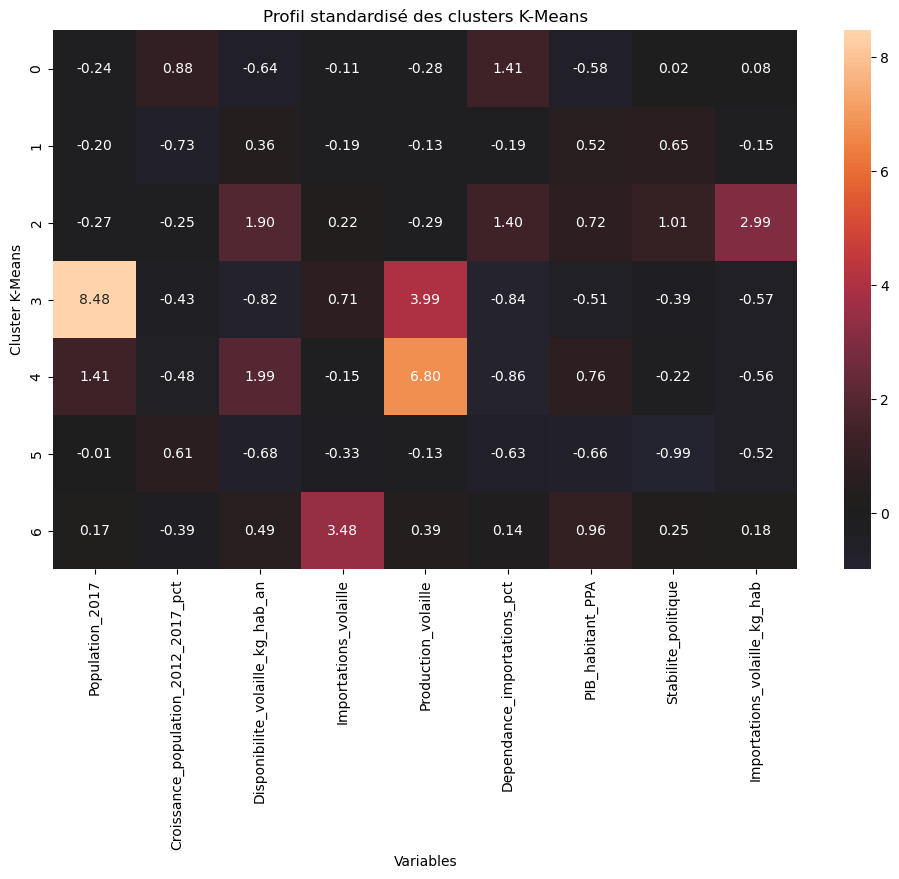

In [97]:
plt.figure(figsize=(12, 7))

sns.heatmap(
    profil_moyen_kmeans,
    annot=True,
    fmt=".2f",
    center=0
)

plt.title("Profil standardisé des clusters K-Means")
plt.xlabel("Variables")
plt.ylabel("Cluster K-Means")

plt.show()

### 5.4 Composition des clusters K-Means

La composition des sept clusters est étudiée afin de relier les profils statistiques identifiés aux pays concernés et de mieux comprendre les différences entre les groupes obtenus.

In [98]:
for cluster in sorted(resultats_kmeans_pays["Cluster_KMeans"].unique()):

    pays_cluster = (
        resultats_kmeans_pays[
            resultats_kmeans_pays["Cluster_KMeans"] == cluster
        ]["Pays"]
        .sort_values()
        .tolist()
    )

    print(f"\nCluster {cluster} ({len(pays_cluster)} pays) :")
    print(", ".join(pays_cluster))


Cluster 0 (22 pays) :
Angola, Belgique, Bénin, Cabo Verde, Congo, République du, Gabon, Gambie, Ghana, Guinée-Bissau, Haïti, Lesotho, Libéria, Mauritanie, Mongolie, Namibie, Oman, République kirghize, Sao Tomé-et-Principe, Tadjikistan, Timor-Leste, Vanuatu, Îles Salomon

Cluster 1 (61 pays) :
Albanie, Argentine, Arménie, Australie, Autriche, Barbade, Bolivie, Bosnie-Herzégovine, Botswana, Bulgarie, Bélarus, Canada, Chili, Chypre, Corée, République de, Costa Rica, Croatie, Danemark, El Salvador, Espagne, Estonie, Fidji, Finlande, Fédération de Russie, Grèce, Guyana, Géorgie, Hongrie, Irlande, Islande, Israël, Italie, Jamaïque, Kazakhstan, Kiribati, Lettonie, Lituanie, Luxembourg, Macédoine du Nord, Malaisie, Malte, Maurice, Moldova, Monténégro, Norvège, Nouvelle-Zélande, Panama, Pologne, Portugal, Roumanie, République dominicaine, République slovaque, République tchèque, Serbie, Slovénie, Suisse, Suriname, Suède, Trinité-et-Tobago, Uruguay, Viet Nam

Cluster 2 (12 pays) :
Antigua-et-Ba

## 6. Comparaison des résultats de clustering

Les partitions obtenues avec la CAH et K-Means sont comparées afin d'identifier les structures communes entre les deux méthodes.

Les numéros attribués aux clusters étant arbitraires et différents selon les algorithmes, la comparaison porte sur la répartition des pays entre les groupes et non sur les numéros des clusters.

In [99]:
# Tableau de comparaison entre les clusters CAH et K-Means

comparaison_clusters = pd.crosstab(
    clusters_cah,
    clusters_kmeans_final,
    rownames=["Cluster_CAH"],
    colnames=["Cluster_KMeans"]
)

display(comparaison_clusters)

Cluster_KMeans,0,1,2,3,4,5,6
Cluster_CAH,,,,,,,
1,21,9,1,0,0,54,0
2,0,0,0,2,2,0,0
3,0,51,0,0,0,0,1
4,0,0,8,0,0,0,0
5,1,1,3,0,0,0,7


In [100]:
from sklearn.metrics import adjusted_rand_score

ari = adjusted_rand_score(
    clusters_cah,
    clusters_kmeans_final
)

print("Adjusted Rand Index :", round(ari, 3))

Adjusted Rand Index : 0.557


## 7. Identification des marchés potentiels

Les résultats de la CAH et de K-Means mettent en évidence plusieurs groupes présentant des caractéristiques potentiellement favorables à l'exportation de volaille.

Le clustering constitue cependant un outil de segmentation et non un classement direct des pays. Les marchés appartenant aux profils les plus pertinents sont donc étudiés à partir de leurs valeurs réelles afin d'identifier les opportunités les plus intéressantes pour l'entreprise.

In [101]:
# Identification des pays appartenant aux profils commerciaux
# les plus intéressants dans les deux méthodes

masque_candidats = (
    (clusters_cah == 5)
    | (clusters_kmeans_final == 6)
    | (clusters_kmeans_final == 2)
)

pays_candidats = donnees.loc[masque_candidats].copy()

# La France correspond au marché domestique actuel de l'entreprise
# et n'est donc pas considérée comme un marché d'expansion.
pays_candidats = pays_candidats[
    pays_candidats["Pays"] != "France"
].copy()

print("Nombre de marchés candidats :", len(pays_candidats))

display(
    pays_candidats[
        [
            "Pays",
            "Population_2017",
            "Importations_volaille",
            "Dependance_importations_pct",
            "Importations_volaille_kg_hab",
            "PIB_habitant_PPA",
            "Stabilite_politique",
            "Production_volaille",
            "Disponibilite_volaille_kg_hab_an"
        ]
    ]
    .sort_values(
        "Importations_volaille",
        ascending=False
    )
    .round(2)
)

Nombre de marchés candidats : 21


,Pays,Population_2017,Importations_volaille,Dependance_importations_pct,Importations_volaille_kg_hab,PIB_habitant_PPA,Stabilite_politique,Production_volaille,Disponibilite_volaille_kg_hab_an
72,Japon,127502.72,1069.0,44.27,8.38,45693.38,85.87,2215.0,18.50
94,Mexique,124777.32,972.0,23.04,7.79,21777.52,48.03,3249.0,32.52
31,"Chine, RAS de Hong Kong",7306.32,907.0,323.93,124.14,65662.85,77.57,24.0,53.51
4,Allemagne,82658.41,842.0,48.42,10.19,61965.43,77.89,1514.0,19.47
117,Royaume-Uni,66727.46,779.0,34.87,11.67,52429.13,73.42,1814.0,31.94
7,Arabie saoudite,33101.18,722.0,50.31,21.81,57942.55,54.49,616.0,43.36
111,Pays-Bas,17021.35,608.0,163.44,35.72,65665.99,79.25,1100.0,20.33
1,Afrique du Sud,57009.76,514.0,24.27,9.02,14573.60,59.36,1667.0,35.69
156,Émirats arabes unis,9487.20,433.0,105.10,45.64,72529.04,78.18,48.0,43.47
16,Belgique,11419.75,338.0,222.37,29.60,58529.33,72.13,463.0,12.65


### 7.1 Sélection d'une shortlist de marchés

Afin d'affiner la sélection parmi les marchés appartenant aux clusters d'intérêt, quatre critères directement liés au potentiel d'exportation et au risque pays sont considérés : le volume d'importations de volaille, la dépendance aux importations, le PIB par habitant en PPA et la stabilité politique.  
Pour éviter de fixer des seuils absolus arbitraires, chaque pays est comparé à la médiane observée parmi les marchés candidats. Un pays est retenu dans la shortlist lorsqu'il présente une valeur supérieure ou égale à la médiane pour au moins trois des quatre critères.  
La population, la production locale et la disponibilité de volaille sont ensuite conservées comme variables d'interprétation afin de différencier les profils des marchés retenus.

In [102]:
criteres_selection = [
    "Importations_volaille",
    "Dependance_importations_pct",
    "PIB_habitant_PPA",
    "Stabilite_politique"
]

seuils_candidats = pays_candidats[criteres_selection].median()

display(seuils_candidats.round(2))

Importations_volaille            137.00
Dependance_importations_pct      100.00
PIB_habitant_PPA               45693.38
Stabilite_politique               78.18
dtype: float64

In [103]:
# Comparaison des candidats aux médianes des marchés présélectionnés

evaluation_candidats = pays_candidats.copy()

evaluation_candidats["Critere_importations"] = (
    evaluation_candidats["Importations_volaille"]
    >= seuils_candidats["Importations_volaille"]
)

evaluation_candidats["Critere_dependance"] = (
    evaluation_candidats["Dependance_importations_pct"]
    >= seuils_candidats["Dependance_importations_pct"]
)

evaluation_candidats["Critere_PIB"] = (
    evaluation_candidats["PIB_habitant_PPA"]
    >= seuils_candidats["PIB_habitant_PPA"]
)

evaluation_candidats["Critere_stabilite"] = (
    evaluation_candidats["Stabilite_politique"]
    >= seuils_candidats["Stabilite_politique"]
)

# Nombre de critères favorables remplis par chaque pays
colonnes_criteres = [
    "Critere_importations",
    "Critere_dependance",
    "Critere_PIB",
    "Critere_stabilite"
]

evaluation_candidats["Nb_criteres_favorables"] = (
    evaluation_candidats[colonnes_criteres].sum(axis=1)
)

# Shortlist : au moins 3 critères favorables sur 4
shortlist = evaluation_candidats[
    evaluation_candidats["Nb_criteres_favorables"] >= 3
].copy()

shortlist = shortlist.sort_values(
    ["Nb_criteres_favorables", "Importations_volaille"],
    ascending=[False, False]
)

display(
    shortlist[
        [
            "Pays",
            "Nb_criteres_favorables",
            "Population_2017",
            "Importations_volaille",
            "Dependance_importations_pct",
            "Importations_volaille_kg_hab",
            "PIB_habitant_PPA",
            "Stabilite_politique",
            "Production_volaille",
            "Disponibilite_volaille_kg_hab_an"
        ]
    ].round(2)
)

,Pays,Nb_criteres_favorables,Population_2017,Importations_volaille,Dependance_importations_pct,Importations_volaille_kg_hab,PIB_habitant_PPA,Stabilite_politique,Production_volaille,Disponibilite_volaille_kg_hab_an
111,Pays-Bas,4,17021.35,608.0,163.44,35.72,65665.99,79.25,1100.0,20.33
156,Émirats arabes unis,4,9487.20,433.0,105.10,45.64,72529.04,78.18,48.0,43.47
72,Japon,3,127502.72,1069.0,44.27,8.38,45693.38,85.87,2215.0,18.50
31,"Chine, RAS de Hong Kong",3,7306.32,907.0,323.93,124.14,65662.85,77.57,24.0,53.51
16,Belgique,3,11419.75,338.0,222.37,29.60,58529.33,72.13,463.0,12.65
32,"Région administrative spéciale de Macao, Chine",3,622.58,23.0,121.05,36.94,133322.63,88.33,3.0,34.47
84,Luxembourg,3,591.91,11.0,100.00,18.58,132169.83,87.61,0.0,18.33


## 8. Conclusion et recommandations

L'analyse a permis de réduire progressivement les **161 pays étudiés** à une sélection de marchés présentant des caractéristiques favorables à l'exportation de volaille.

L'ACP et les méthodes de clustering ont fait ressortir plusieurs profils de pays. En croisant ces résultats avec quatre critères — **volume d'importations, dépendance aux importations, niveau économique et stabilité politique** — une shortlist de **7 marchés** a été identifiée :

**Pays-Bas, Émirats arabes unis, Japon, Hong Kong, Belgique, Macao et Luxembourg.**

Parmi eux, les **Pays-Bas et les Émirats arabes unis** répondent aux quatre critères étudiés, tandis que le **Japon** se distingue notamment par l'importance de son marché et de ses importations.

Cette sélection constitue une **première orientation pour l'expansion internationale** de *La Poule qui chante*. Une analyse complémentaire des contraintes réglementaires, logistiques et concurrentielles sera nécessaire avant de retenir définitivement les marchés à cibler.